# Lab 2. Monte Carlo methods

In this task you need to implement:
- Implement Langevin dynamics for sampling from posterior distribution
- Implement Stochastic Langevin dynamics for sampling from posterior distribution
- Apply both methods to the toy problem of estimating the parameters of a mixture of normal distributions
- *(bonus)* Apply Langevin dynamics to generate images

The assessment is based on the augmented code in the cells (calculation of gradients for the toy problem, Langevin dynamics and stochastic Langevin dynamics), as well as answers to questions about the experiments. The bonus part of the challenge uses the output of a convolutional neural network as the unnormalized density, so you may need a GPU, a cloud server, or a little patience to complete it.

Papers:

- Welling M., Teh Y. W. Bayesian learning via stochastic gradient Langevin dynamics // Proceedings of the 28th International Conference on Machine Learning (ICML-11). – 2011. – P. 681-688.
- Neal R. M. et al. MCMC using Hamiltonian dynamics // Handbook of Markov Chain Monte Carlo. – 2011. – V. 2. – No. 11
- Grathwohl W. et al. Your Classifier is Secretly an Energy Based Model and You Should Treat it Like One // ICLR 2020

Criteria for evaluation:
1. Functions for calculating densities in a model problem - 2 points
2. Stochastic Langevin dynamics - 2 points
3. Langevin dynamics - 2 points
4. Comments on experiments 1 - 1.5 points
5. Comments on experiments 2 - 1.5 points
6. Comments on experiments 3 - 1 point
7. Bonus part - 2 points maximum

In [1]:
# numpy==1.19.5
# jax==0.2.21
# matplotlib==3.2.2
# tqdm==4.62.3
# flax==0.3.6

import matplotlib.pylab as plt
import numpy as onp
import jax.numpy as np
import jax

import copy
import gzip
import os

from jax.scipy.stats import norm
from tqdm import tqdm

# JAX GPU can be installed according to the instructions: https://github.com/google/jax
# The next line removes the warning if you don't have a gpu or tpu
jax.config.update('jax_platform_name', 'cpu')
%matplotlib inline


### About libraries for lab

Since Langevin dynamics requires density gradients, in this assignment we will use the JAX library to calculate them. JAX overrides much of the numpy library in the jax.numpy module and adds features for automatic construction of function gradients;

In [2]:
def foo(x):
    return np.sin(x)

grad_foo = jax.grad(foo)
x = 0.
print("f(0) = {}, f'(0) = {}".format(foo(x), grad_foo(x)))

f(0) = 0.0, f'(0) = 1.0


- Function Vectorizations;

In [3]:
# np.cos is already vectorized, but jax.vmap adds vector dimension for more complex Python functions
vector_grad_foo = jax.vmap(grad_foo)
# vector_grad_foo(0.) doesn't work now
vector_grad_foo(0.5 * np.pi * np.arange(8))

Array([ 1.0000000e+00, -4.3711388e-08, -1.0000000e+00,  1.1924881e-08,
        1.0000000e+00, -3.3776624e-07, -1.0000000e+00,  6.6360758e-07],      dtype=float32, weak_type=True)

- Performing calculations on accelerators and compiling "just-in-time" functions

In [4]:
x = 0.5 * np.pi * np.arange(100)

%timeit vector_grad_foo(x)
vector_grad_foo = jax.jit(vector_grad_foo) # compiling a function
%timeit vector_grad_foo(x)
%timeit np.cos(x) # this is how the library function works

528 μs ± 25.7 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
4.75 μs ± 123 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)
4.65 μs ± 31.4 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


The jax.numpy module can be used similarly to the numpy library. The main exception is the generation of random numbers: for this, jax has a jax.random module, which you can read about [here](https://jax.readthedocs.io/en/latest/notebooks/Common_Gotchas_in_JAX.html#%F0%9F%94%AA-Random-Numbers). **Tl;dr: to generate, you need to pass a unique key each time.**

In [5]:
rng = jax.random.PRNGKey(seed=42)
rng, key = jax.random.split(rng)
n = jax.random.normal(key, (3,))
print('Random sample:\n{}'.format(n))
n = jax.random.normal(key, (3,))
print('Same key, same sample:\n{}'.format(n))
rng, key = jax.random.split(rng)
n = jax.random.normal(key, (3, ))
print('New key, new sample:\n{}'.format(n))

Random sample:
[ 0.60576403  0.7990441  -0.908927  ]
Same key, same sample:
[ 0.60576403  0.7990441  -0.908927  ]
New key, new sample:
[-0.21089035 -1.3627948  -0.04500385]


We recommend using jax.random when sampling in Langevin dynamics: it is faster and more “random”. However, for simplicity, we will initialize the weights using *numpy.random*.

# The problem of estimating the parameters of a mixture of distributions

> In a probabilistic model, data is sampled from a mixture of normal distributions:

>\begin{align}
& \theta_1 \sim N(0,\sigma_1^2); \quad \theta_2 \sim N(0, \sigma_2^2) \\
& \\
& x_i \overset{i.i.d.}{\sim} \frac{1}{2} N(\theta_1, \sigma_x^2) + \frac{1}{2} N(\theta_1 + \theta_2, \sigma_x^2) \quad i=1,\dots,N \\
\end{align}

>The parameters $\theta_1$ and $\theta_2$ have prior normal distributions, the remaining parameters are assumed to be equal
\begin{align}
& \sigma_x^2 = 2 \\
& \sigma_1^2 = 10 \\
& \sigma_2^2 = 1 \\
\end{align}

>Let sample $X$ be generated with parameters $\theta_1 = 0$, $\theta_2 = 1$. Sample $X$ consists of $N=100$ elements. Using a sample $X$, it is required to construct samples from the posterior distribution $p({\bar \theta} | X, \sigma_x, \sigma_1, \sigma_2)$.

Let's construct a sample from this distribution:

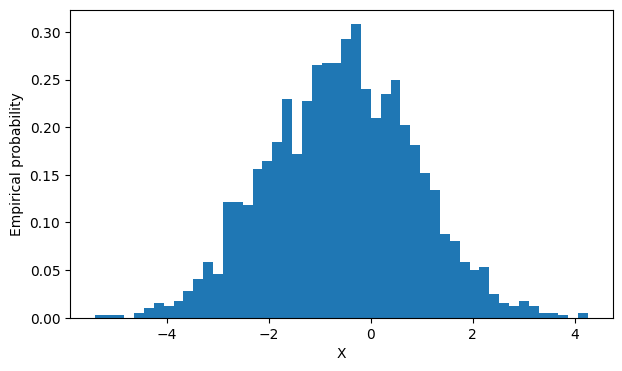

In [6]:
def generate_mixture_data(N, theta_1=None, theta_2=None, seed=6):
    """
    The function generates a sample of a given size from the probabilistic model described above.
    In the case where a scalar value is passed for theta_1 or theta_2, the passed value is used
    instead of a random parameter value from the prior distribution.
    """
    onp.random.seed(seed)
    sigma_x = np.sqrt(2.)
    if theta_1 is None:
        sigma_1 = np.sqrt(10.)
        theta_1 = sigma_1 * onp.random.randn()
    if theta_2 is None:
        sigma_2 = 1.
        theta_2 = sigma_2 * onp.random.randn()
    mixture_component = onp.random.randint(0, 2, N).astype(onp.bool)
    first_component = theta_1 + sigma_x * onp.random.randn(N)
    second_component = (theta_1 + theta_2) + sigma_x * onp.random.randn(N)
    samples = np.where(mixture_component,
                       first_component,
                       second_component)
    return samples

# Example of a sample from the model described above

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(generate_mixture_data(2048), bins=50, density=True)
ax.set_xlabel('X')
ax.set_ylabel('Empirical probability');

Our main goal is to construct a posterior distribution for their values using the sample obtained for fixed values of $\theta_1$ and $\theta_2$.

\begin{equation}
p({\bar \theta} | X, \sigma_x, \sigma_1, \sigma_2) \propto \left[ \prod_{i=1}^{N} p(X| {\bar \theta}, \sigma_x) \right] p(\theta | \sigma_1, \sigma_2)
\end{equation}

Although the problem allows for analytical calculation of the posterior distribution, after opening the brackets it will be a mixture of $2^N$ normal distributions. Therefore, even for such a simple problem, analytical inference may not be effective in practice.

Monte Carlo methods produce samples from a posterior distribution.

> For our purposes, we will need functions to calculate the density of the prior distribution and the log likelihood. Implement:

In [9]:
def log_p_prior(weights):
    """
    Logarithm of the density of the prior distribution.
    Input:
        weights - the vector consists of two real numbers \theta_1, \theta_2
    Output: number
    """
    theta_1, theta_2 = weights[0], weights[1]
    sigma_1 = np.sqrt(10.)  # σ₁² = 10
    sigma_2 = 1.            # σ₂² = 1
    # log p(θ₁) + log p(θ₂)
    log_p_theta_1 = norm.logpdf(theta_1, loc=0., scale=sigma_1)
    log_p_theta_2 = norm.logpdf(theta_2, loc=0., scale=sigma_2)
    return log_p_theta_1 + log_p_theta_2

def log_p_likelihood(weights, x):
    """
    Returns the logarithm of the likelihood of the data x with respect to the parameters weights
    Input:
        weights - the vector consists of two real numbers \theta_1, \theta_2,
        x - data (fixed size vector)
    Output: number
    """
    theta_1, theta_2 = weights[0], weights[1]
    sigma_x = np.sqrt(2.)  # σ_x² = 2
    
    # x_i ~ 0.5 * N(θ₁, σ_x²) + 0.5 * N(θ₁ + θ₂, σ_x²)
    # log p(x_i | θ) = log [0.5 * N(x_i | θ₁, σ_x²) + 0.5 * N(x_i | θ₁ + θ₂, σ_x²)]
    log_p_1 = norm.logpdf(x, loc=theta_1, scale=sigma_x)
    log_p_2 = norm.logpdf(x, loc=theta_1 + theta_2, scale=sigma_x)
    
    # Use logsumexp for numerical stability: log(0.5 * exp(log_p_1) + 0.5 * exp(log_p_2))
    # = logsumexp([log_p_1, log_p_2]) - log(2)
    log_mixture = jax.scipy.special.logsumexp(
        np.stack([log_p_1, log_p_2], axis=-1), axis=-1
    ) - np.log(2.)
    
    # Sum over all data points
    return np.sum(log_mixture)

def log_p_joint(weights, x):
    return log_p_likelihood(weights, x) + log_p_prior(weights)

# Let's define a function for the gradient and vectorize both functions to calculate parameters by batch:
grad_log_p_joint = jax.grad(log_p_joint)
# vectorize only by the first argument
log_p_joint = jax.vmap(log_p_joint, (0, None))
grad_log_p_joint = jax.vmap(grad_log_p_joint, (0, None))
# compilation to speed up, you can try skipping this step
log_p_joint = jax.jit(log_p_joint)
grad_log_p_joint = jax.jit(grad_log_p_joint)

According to the problem, we receive a sample of one hundred observations $x_i$ obtained with values $\theta_1=0$ and $\theta_2=1$.

Let us approximate the density of the posterior distribution as a function of the number of received observations:

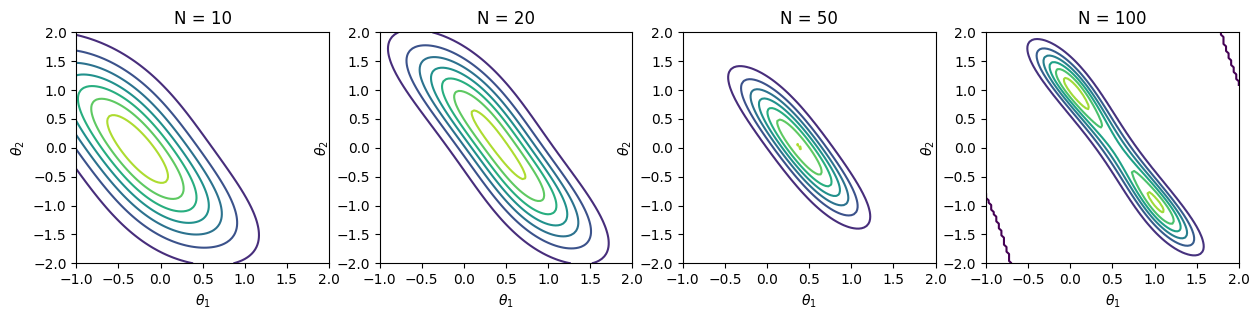

In [10]:
rng = jax.random.PRNGKey(seed=42)
rng, key = jax.random.split(rng)
data = generate_mixture_data(N=100, theta_1=0, theta_2=1)

def plot_posterior(axes, data, resolution=100):
    theta_1 = np.linspace(-1., 2., resolution)
    theta_2 = np.linspace(-2., 2., resolution)
    X, Y = np.meshgrid(theta_1, theta_2)
    weights = np.stack((X.reshape(-1), Y.reshape(-1)), 1)
    log_probs = log_p_joint(weights, data)
    log_probs = log_probs - log_probs.max()
    Z = np.exp(log_probs - log_probs.max())
    norm_const = np.sum(Z) * 3 * 4 / resolution ** 2
    Z /= norm_const
    Z = Z.reshape((resolution, resolution))

    CS = axes.contour(X, Y, Z)
    axes.set_xlabel(r'$\theta_1$')
    axes.set_ylabel(r'$\theta_2$')

Ns = (10, 20, 50, 100,)
fig, axes = plt.subplots(ncols=len(Ns), figsize=(15, 3))
for n, ax in zip(Ns, axes):
    plot_posterior(ax, data[:n])
    ax.set_title('N = %d' % n)

> The posterior distribution in the last graph should have two distinct modes. How can this be explained?

**Answer:**

The posterior distribution has two distinct modes because of the **symmetry in the mixture model**. 

The data is generated from a mixture of two Gaussians:
- Component 1: $N(\theta_1, \sigma_x^2)$
- Component 2: $N(\theta_1 + \theta_2, \sigma_x^2)$

The true parameters are $\theta_1 = 0$ and $\theta_2 = 1$, giving means at 0 and 1.

However, from the data alone, we cannot distinguish which component is which. The model is **label-invariant**: swapping the roles of the two components gives the same likelihood. Specifically:
- $(\theta_1 = 0, \theta_2 = 1)$ gives means at 0 and 1
- $(\theta_1 = 1, \theta_2 = -1)$ gives means at 1 and 0 (same mixture!)

This creates two symmetric modes in the posterior:
1. One mode near $(\theta_1 \approx 0, \theta_2 \approx 1)$ — the true parameters
2. Another mode near $(\theta_1 \approx 0.5, \theta_2 \approx -1)$ — the "swapped" solution

The prior distribution slightly breaks this symmetry (since $\sigma_1^2 = 10 \neq \sigma_2^2 = 1$), but with enough data, the likelihood dominates and both modes remain prominent.


> Below you need to implement functions for constructing samples from the posterior distribution:

> 1. Stochastic Langevin dynamics. To implement it, it is enough to slightly modify the proposed implementation of gradient ascent
> 2. Langevin dynamics with acceptance of points according to the Metropolis-Hastings scheme
     - Calculation of new weights
     - Calculating the probability of accepting these weights
     - Random acceptance of part of the scales

In [11]:
def gradient_ascent_update(epsilon, gradient, weights, rng):
    return weights + 0.5 * epsilon * gradient

def stochastic_langevin_update(epsilon, gradient, weights, rng):
    """
    Stochastic Langevin dynamics
    Input:
        epsilon - gradient step size
        gradient - real matrix with gradients for pairs $\theta$
        weights -  real matrix with parameters $\theta$
        rng - seed for generating random numbers
    Output:
        real matrix corresponding to the updated parameters $\theta$
    """
    noise = jax.random.normal(rng, weights.shape)
    return weights + 0.5 * epsilon * gradient + np.sqrt(epsilon) * noise

def mh_acceptance_ratio(epsilon, weights, new_weights):
    """
    Langevin dynamics
    Input:
        epsilon - gradient step size
        weights -  real matrix with parameters $\theta$
        new_weigts - parameters obtained after the Langevin scheme step
    Output:
        real vector specifying the logarithm of the probability of accepting each pair from the batch
    """
    # Compute log joint probabilities using global log_p_joint and data
    log_p_new = log_p_joint(new_weights, data)
    log_p_old = log_p_joint(weights, data)
    
    # Return log acceptance ratio
    return log_p_new - log_p_old

def langevin_update(epsilon, gradient, weights, rng):
    """
   Langevin dynamics
    Input:
        epsilon - gradient step size
        gradient - real matrix with gradients for $\theta$ pairs
        weights -  real matrix with parameters $\theta$
        rng - seed for generating random numbers
    Output:
        real matrix corresponding to the updated parameters $\theta$
        real number, the fraction of accepted points from the batch
    """
    # Split random key for noise and acceptance
    rng, key_noise, key_accept = jax.random.split(rng, 3)
    
    # Propose new weights: θ' = θ + (ε/2) * ∇log p(θ) + √ε * ξ
    noise = jax.random.normal(key_noise, weights.shape)
    new_weights = weights + 0.5 * epsilon * gradient + np.sqrt(epsilon) * noise
    
    # Compute log acceptance ratio
    log_accept_ratio = mh_acceptance_ratio(epsilon, weights, new_weights)
    
    # Sample uniform for accept/reject decision
    u = jax.random.uniform(key_accept, (weights.shape[0],))
    accept = np.log(u) < log_accept_ratio
    
    # Update weights: keep new if accepted, otherwise keep old
    updated_weights = np.where(accept[:, None], new_weights, weights)
    
    # Return updated weights and fraction of accepted proposals
    return updated_weights, accept.mean()

## Langevin dynamics on a toy problem

Let's define several auxiliary functions

In [12]:
def append_ema(array, value, alpha=0.05):
    """
    Adding elements to an array with exponential smoothing
    """
    if not array:
        array.append(value)
    else:
        array.append((1 - alpha) * array[-1] + alpha * value)
    return array

def train_mixture(data, weights, epsilon, n_epochs=2000, n_trajectories=5):
    """
    Plotting points from the posterior distribution using Langevin dynamics.
    In parallel with the construction of points, the trajectories of n_trajectories
    of points and the dynamics of acceptance_rate are saved
    """
    rng = jax.random.PRNGKey(27)
    acceptance_rate = []
    theta_dynamics = []
    for epoch in tqdm(range(n_epochs)):
        theta_dynamics.append(copy.copy(weights[:n_trajectories]))
        gradient = grad_log_p_joint(weights, data)
        rng, key = jax.random.split(rng)
        weights, accepted = langevin_update(epsilon, gradient, weights, key)
        append_ema(acceptance_rate, accepted)
    theta_dynamics = np.asarray(theta_dynamics)
    return weights, acceptance_rate, theta_dynamics

Let's run M Langevin schemes with step $\varepsilon = 10^{-3}$ and step $\varepsilon = 10^{-4}$

In [13]:
M = 128

weights_a = onp.random.randn(M, 2)
weights_b = onp.random.randn(M, 2)

weights_a, acceptance_rates_a, theta_dynamics_a = train_mixture(data, weights_a, 1e-3)
weights_b, acceptance_rates_b, theta_dynamics_b = train_mixture(data, weights_b, 1e-4)

100%|██████████| 2000/2000 [00:01<00:00, 1890.98it/s]


The next cell contains four graphs:
1. Two sets of M points from parallel running Langevin dynamics after 2000 iterations
2. Dynamics of five points from the diagram with a step of $\varepsilon=10^{-3}$
3. Dynamics of five points from the diagram with a step of $\varepsilon=10^{-4}$
4. Fraction of accepted points (from M parallel dynamics) after each iteration for different steps

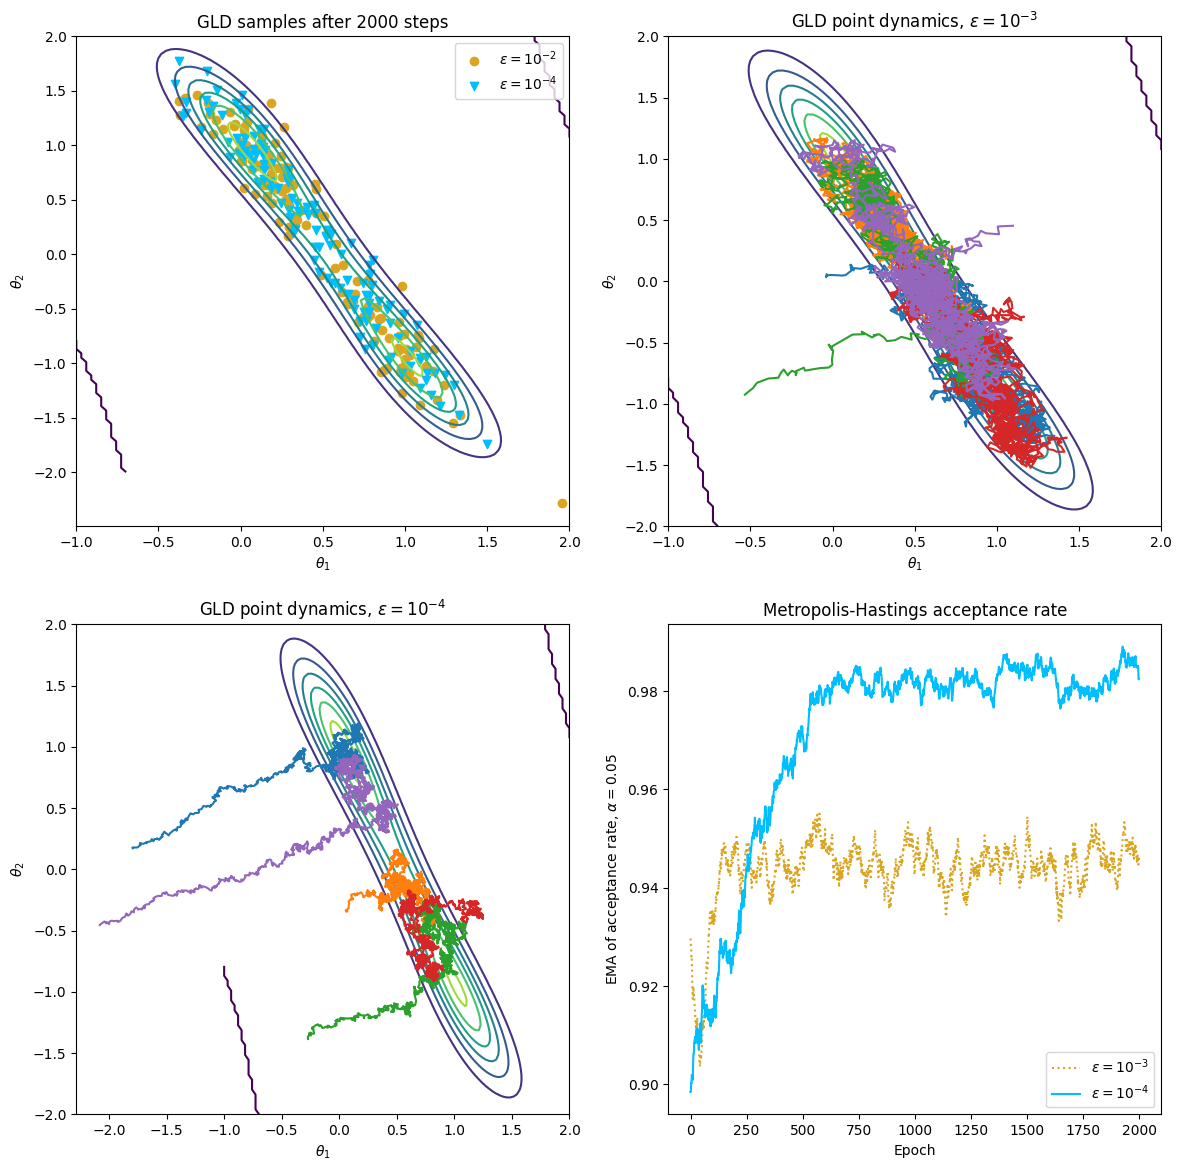

In [14]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 14))

plot_posterior(axes[0][0], data)
axes[0][0].scatter(weights_a[..., 0],
                   weights_a[..., 1],
                   marker='o',
                   c='goldenrod',
                   label=r'$\varepsilon=10^{-2}$')
axes[0][0].scatter(weights_b[..., 0],
                   weights_b[..., 1],
                   marker='v',
                   c='deepskyblue',
                   label=r'$\varepsilon=10^{-4}$')
axes[0][0].set_title('GLD samples after 2000 steps')
axes[0][0].legend(loc='upper right')

plot_posterior(axes[0][1], data)
plot_posterior(axes[1][0], data)
axes[0][1].set_title(r'GLD point dynamics, $\varepsilon=10^{-3}$')
axes[1][0].set_title(r'GLD point dynamics, $\varepsilon=10^{-4}$')

for i in range(5):
    axes[0][1].plot(theta_dynamics_a[:, i, 0], theta_dynamics_a[:, i, 1])
    axes[1][0].plot(theta_dynamics_b[:, i, 0], theta_dynamics_b[:, i, 1])

axes[1][1].plot(acceptance_rates_a, label=r'$\varepsilon=10^{-3}$', ls=':', c='goldenrod')
axes[1][1].plot(acceptance_rates_b, label=r'$\varepsilon=10^{-4}$', ls='-', c='deepskyblue')
axes[1][1].set_title('Metropolis-Hastings acceptance rate')
axes[1][1].set_xlabel('Epoch')
axes[1][1].set_ylabel(r'EMA of acceptance rate, $\alpha = 0.05$')
axes[1][1].legend(loc='lower right');

> Based on these graphs, answer the following questions:
- Do the points cover the posterior distribution well?
- Do the points manage to “jump” from one mode to another?
- How does the proportion of accepted points change depending on the step size?
- Based on what considerations should one choose the step size in Langevin dynamics?

1. Do the points cover the posterior distribution well?

Yes, the "GLD samples after 2000 steps" plot shows that:
- Points with $\varepsilon = 10^{-3}$ (yellow circles) cover both modes of the posterior distribution well and are spread along the density contours
- Points with $\varepsilon = 10^{-4}$ (blue triangles) also cover both modes but are more compactly located around the mode centers

Both groups of points correctly reflect the bimodal structure of the posterior distribution.

2. Do the points manage to "jump" from one mode to another?

Based on the trajectory plots:
- With $\varepsilon = 10^{-3}$: trajectories are more chaotic and wide-ranging, points can move large distances in a single step. The plot shows that some trajectories cross the space between modes
- With $\varepsilon = 10^{-4}$: trajectories are significantly smoother and more localized. Points move slowly and stay near the mode where they started. Transitions between modes over 2000 iterations practically do not occur — trajectories get "stuck" in the local mode

3. How does the proportion of accepted points change depending on the step size?

The "Metropolis-Hastings acceptance rate" plot clearly shows:
- With $\varepsilon = 10^{-4}$ (blue line): acceptance rate is close to 1.0 (almost all proposals are accepted)
- With $\varepsilon = 10^{-3}$ (yellow dotted line): acceptance rate is significantly lower, around 0.6-0.8

This is expected: with a small step, proposed points are close to the current position and have comparable density with high probability, so they are accepted. With a large step, points may end up in low-density regions and be rejected.

4. Based on what considerations should one choose the step size in Langevin dynamics?

Based on the graphs, we can conclude:
- Too large step ($\varepsilon = 10^{-3}$): low acceptance rate (~0.6-0.8), many rejected proposals, but better mixing between modes
- Too small step ($\varepsilon = 10^{-4}$): high acceptance rate (~1.0), but slow exploration of the space and poor mixing between modes

Optimal choice:
- Target acceptance rate around 0.5-0.7 (empirical rule for MALA)
- Step size should be adapted to the scale of the target distribution
- For multimodal distributions, adaptive tuning or tempered methods may be needed for better mixing


## Stochastic Langevin dynamics on a toy problem

Let's define a few more auxiliary functions

In [15]:
# stochastic joint likelihood estimation
def log_p_joint_estimate(weights, x, N_over_n):
    return N_over_n * log_p_likelihood(weights, x) + log_p_prior(weights)
# stochastic gradient
grad_log_p_joint_estimate = jax.grad(log_p_joint_estimate)

log_p_joint_estimate = jax.jit(jax.vmap(log_p_joint_estimate, (0, None, None)))
grad_log_p_joint_estimate = jax.jit(jax.vmap(grad_log_p_joint_estimate, (0, None, None)))

# let's define a vector of gradients $\nablda log p(x_i), i=1, \dots, N$ to calculate the variance relative to the choice of data
batch_gradients = jax.vmap(jax.grad(log_p_likelihood), (None, 0))

In [16]:
def iterate_data(rng, length, batchsize=100, shuffle=True):
    """
    Function for passing through a sample
    """
    indices = onp.arange(length)
    if shuffle:
        onp.random.shuffle(indices)
    for start_idx in range(0, length - batchsize + 1, batchsize):
        yield indices[start_idx:start_idx + batchsize]

def stochastic_train_mixture(rng, data, weights, method, n_epochs=2000, n=10, n_trajectories=5):
    """
    Plotting points from the posterior distribution using Langevin stochastic dynamics
    In parallel with the construction of points, the trajectories of n_trajectories of points after each epoch,
    estimates of the dispersions of the stochastic gradient and the dispersion of the additional noise of the Langevin dynamics are saved
    """
    noise_vars = []
    theta_vars = []
    theta_dynamics = []
    N_over_n = len(data) / n
    steps_counter = 0
    for epochs in tqdm(range(n_epochs)):
        epsilon = 1e-1 * (steps_counter + 1e1) ** (-0.55)
        rng, key = jax.random.split(rng)
        for indices in iterate_data(key, len(data), n):
            rng, key = jax.random.split(rng)
            gradient = grad_log_p_joint_estimate(weights, data[indices], N_over_n)
            weights = method(epsilon, gradient, weights, key)
            steps_counter += 1

        theta_dynamics.append(copy.copy(weights[:n_trajectories, :]))
        # just like in the paper, we estimate variances based on a subsample
        rng, key = jax.random.split(rng)
        theta_grad = batch_gradients(weights, data)
        theta_vars.append(theta_grad.var(0).max(0) * (0.5 * epsilon * N_over_n) ** 2 * n)
        noise_vars.append(epsilon)

    theta_dynamics = np.asarray(theta_dynamics)
    theta_vars = np.asarray(theta_vars)
    noise_vars = np.asarray(noise_vars)

    return weights, noise_vars, theta_vars, theta_dynamics

Let's run stochastic Langevin dynamics and stochastic gradient ascent

In [17]:
M = 128
n = 10
n_trajectories = 5

weights_a = onp.random.randn(M, 2)
weights_b = onp.random.randn(M, 2)

weights_a, noise_vars_a, theta_vars_a, theta_dynamics_a = stochastic_train_mixture(
    rng, data, weights_a, stochastic_langevin_update, n_epochs=200
)

weights_b, _, theta_vars_b, theta_dynamics_b = stochastic_train_mixture(
    rng, data, weights_b, gradient_ascent_update, n_epochs=200
)

100%|██████████| 200/200 [00:03<00:00, 63.65it/s]


In the next cell four graphs are plotted:

1. M points from parallel running Langevin dynamics after 2000 epochs and M points from parallel perturbed stochastic gradient descents after 2000 epochs
2. Trajectories of five points when moving according to Langevin’s stochastic dynamics
3. Trajectories of five points when moving in the direction of the stochastic gradient
4. Variances of stochastic gradients and additional noise of stochastic Langevin dynamics depending on the epoch

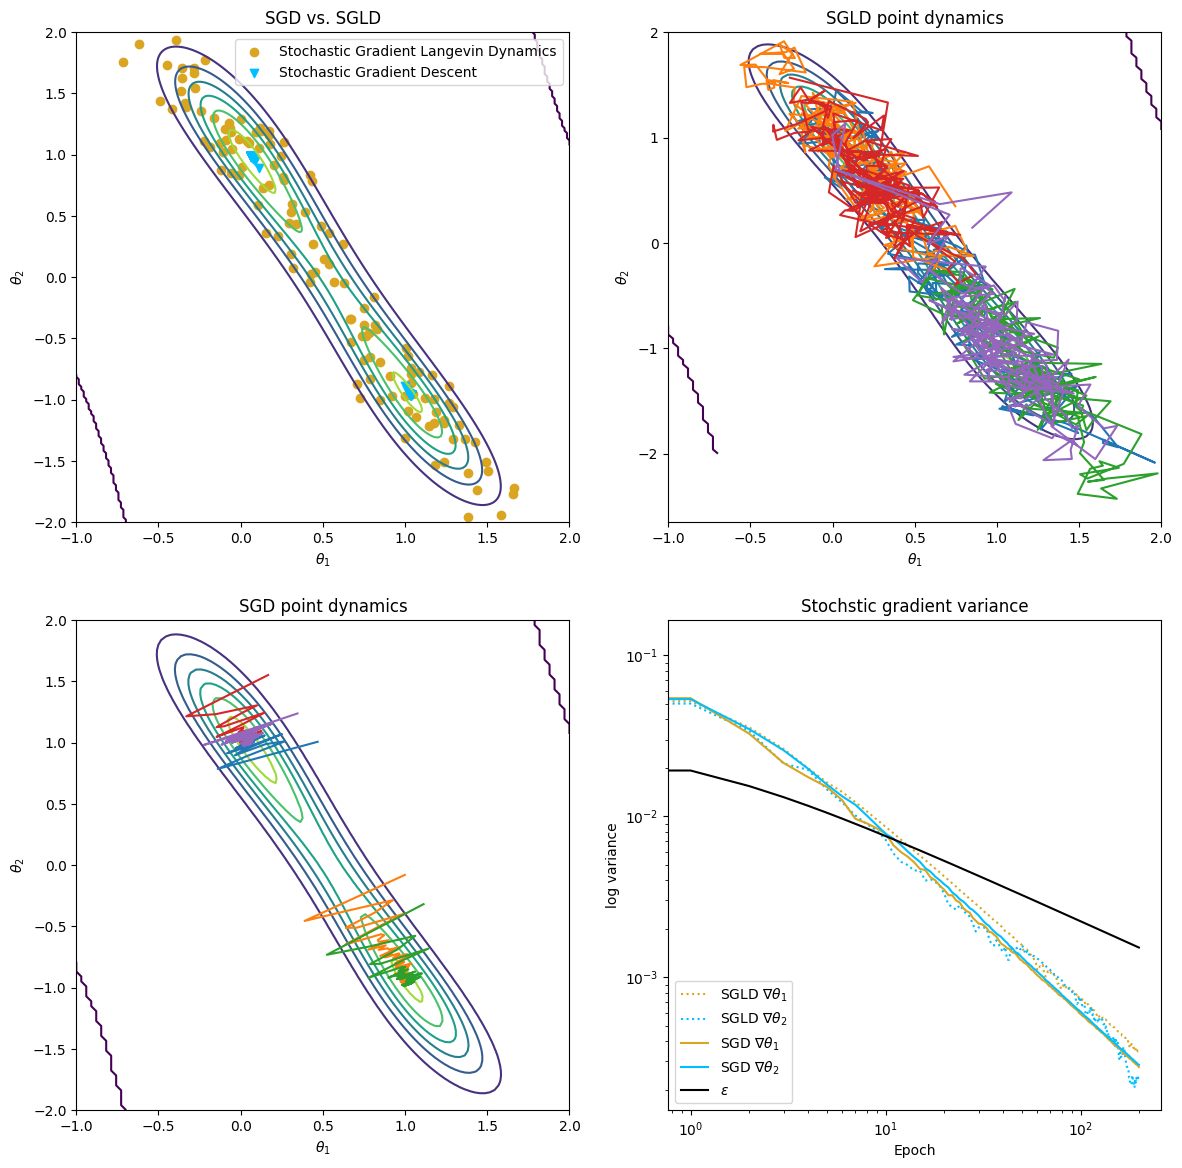

In [18]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 14))

plot_posterior(axes[0][0], data, 200)
axes[0][0].scatter(weights_a[:, 0],
                   weights_a[:, 1],
                   c='goldenrod',
                   label='Stochastic Gradient Langevin Dynamics')
axes[0][0].scatter(weights_b[:, 0],
                   weights_b[:, 1],
                   marker='v',
                   c='deepskyblue',
                   label='Stochastic Gradient Descent')
axes[0][0].set_title('SGD vs. SGLD')
axes[0][0].legend(loc='upper right')

plot_posterior(axes[0][1], data)
plot_posterior(axes[1][0], data)
axes[0][1].set_title(r'SGLD point dynamics')
axes[1][0].set_title(r'SGD point dynamics')

for i in range(5):
    axes[0][1].plot(theta_dynamics_a[:, i, 0], theta_dynamics_a[:, i, 1])
    axes[1][0].plot(theta_dynamics_b[:, i, 0], theta_dynamics_b[:, i, 1])

axes[1][1].set_title('Stochstic gradient variance')
axes[1][1].set_yscale("log", nonpositive='clip')
axes[1][1].set_xscale("log", nonpositive='clip')
axes[1][1].plot(theta_vars_a[:, 0], label=r'SGLD $\nabla \theta_1$', c='goldenrod', ls=':')
axes[1][1].plot(theta_vars_a[:, 1], label=r'SGLD $\nabla \theta_2$', c='deepskyblue', ls=':')
axes[1][1].plot(theta_vars_b[:, 0], label=r'SGD $\nabla \theta_1$', c='goldenrod', ls='-')
axes[1][1].plot(theta_vars_b[:, 1], label=r'SGD $\nabla \theta_2$', c='deepskyblue', ls='-')
axes[1][1].plot(noise_vars_a, label=r'$\varepsilon$', c='black')
axes[1][1].set_xlabel('Epoch')
axes[1][1].set_ylabel('log variance')
axes[1][1].legend(loc='lower left');

> Based on the graphs, answer the following questions:
1. Do the represented points cover the posterior distribution well? Where do the points gather after the gradient ascent?
3. Does Langevin’s stochastic dynamics manage to “jump” from one mode to another?
4. How do the dispersions of stochastic gradients relate to the dispersion of the added noise of the Langevin dynamics?

1. Do the represented points cover the posterior distribution well? Where do the points gather after the gradient ascent?

- SGLD (yellow points): The points cover the posterior distribution well, distributed across both modes. The sampler explores the full distribution thanks to the injected noise, producing genuine samples from the posterior.

- SGD (blue triangles): The points do NOT cover the posterior distribution. Instead, they converge to two tight clusters located exactly at the modes (local maxima) of the posterior. Each chain converges to one mode and stays there permanently. SGD produces point estimates (MAP), not samples from the distribution.

2. Does Langevin's stochastic dynamics manage to "jump" from one mode to another?

- SGLD trajectories: Initially, when $\varepsilon$ is large, trajectories explore the space more freely. Some trajectories may cross between modes during early iterations. However, as the step size decays ($\varepsilon \propto t^{-0.55}$), the dynamics become more localized, and points tend to settle near one mode.

- SGD trajectories: Trajectories converge smoothly and directly toward the nearest mode, with no jumping between modes. Each trajectory finds its local maximum and stops there.

3. How do the dispersions of stochastic gradients relate to the dispersion of the added noise of the Langevin dynamics?


- Gradient variance lines (colored, both solid and dotted): These represent the variance of the stochastic gradient scaled by the step size. They decrease over epochs as $\varepsilon$ decreases.

- Black line ($\varepsilon$): This represents the injected Langevin noise variance.

#Bonus

In “Your Classifier is Secretly an Energy Based Model and You Should Treat it Like One,” the authors propose to approximate the unnormalized density $\hat{p}(x, y)$ of CIFAR-10 data using a neural network designed for discriminative classification. The model they trained turns out to be simultaneously applicable for both classification and data generation. For the latter, the Langevin scheme is needed.

In this part of the task, we propose to implement a scheme for sampling from a pre-trained model posted [in the authors' repository](https://github.com/wgrathwohl/JEM/). There you can also find an approximate sampling scheme: without the Metropolis-Hastings correction and with inconsistent multipliers before the gradient and additional noise.

Try to implement the most reasonable sampling scheme and get samples from CIFAR-10. Think about how the choice of starting points affects the sampling speed? How well is the density determined for argumnets that are not similar to the CIFAR-10 images? How to implement conditional and unconditional generation?

For convenience, we attach a script to the task that allows you to load a pre-trained model, calculate the value of the logarithm of the unnormalized density and density gradients from the input image. An example of their use is given below.

In [ ]:
# install the library to launch wideresnet and download the pre-trained weights
!pip3 install flax

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/pty.py:95: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  pid, fd = os.forkpty()


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: /Library/Frameworks/Python.framework/Versions/3.12/bin/python3.12 -m pip install --upgrade pip


In [24]:
!wget 'https://www.dropbox.com/s/2zsrsy0q48zlnuy/cifar10_pretrained.pt'

--2025-11-26 15:20:01--  https://www.dropbox.com/s/2zsrsy0q48zlnuy/cifar10_pretrained.pt
Resolving www.dropbox.com (www.dropbox.com)... 162.125.66.18
Connecting to www.dropbox.com (www.dropbox.com)|162.125.66.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.dropbox.com/scl/fi/unr4jjhcjn4j7aulyw76r/cifar10_pretrained.pt?rlkey=9ybm6j8j7ly31hitwd9p5lq7i [following]
--2025-11-26 15:20:02--  https://www.dropbox.com/scl/fi/unr4jjhcjn4j7aulyw76r/cifar10_pretrained.pt?rlkey=9ybm6j8j7ly31hitwd9p5lq7i
Reusing existing connection to www.dropbox.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://uc58217455b0ee2f21764ca377f8.dl.dropboxusercontent.com/cd/0/inline/C15Vt5Kch6LMJokkiTCiXmcGkxHpfjGqD_YkXXpVBFLaD7ZT6SO8TPq3nPiHCyCJOiXW_46Fxx4vtZqj7Tpx5qw8qjP8vXBY-Neff5AzAUTVCnUQ_HIKLxftFiDw-K1cVdkY9BYna7VAerpkEiO7WKMM/file# [following]
--2025-11-26 15:20:03--  https://uc58217455b0ee2f21764ca377f8.dl.dropboxusercontent.com/cd/0/inline/

In [25]:
from wideresnet import load_pretrained_model, get_grads_wrt_input
path_to_pretrained_model = "./cifar10_pretrained.pt"
params = load_pretrained_model(path_to_pretrained_model)

batch_size = 4
x = onp.random.randn(batch_size, 32, 32, 3)
y = onp.random.randint(10, size=(batch_size, ))

log_p, input_grads = get_grads_wrt_input(params, x)
log_p, input_grads = get_grads_wrt_input(params, x, y)

In [26]:
def langevin_image_sampling(params, 
                            n_samples=16, 
                            n_steps=100, 
                            epsilon=0.01, 
                            noise_scale=0.005,
                            y=None,
                            init_noise_scale=1.0):

    rng = jax.random.PRNGKey(42)
    
    rng, key = jax.random.split(rng)
    x = init_noise_scale * jax.random.uniform(key, (n_samples, 32, 32, 3), minval=-1, maxval=1)
    
    for step in tqdm(range(n_steps)):
        if y is not None:
            log_p, grad_x = get_grads_wrt_input(params, x, y)
        else:
            log_p, grad_x = get_grads_wrt_input(params, x)
        
        # Langevin dynamics update: x = x + epsilon * grad + sqrt(2*epsilon) * noise
        rng, key = jax.random.split(rng)
        noise = jax.random.normal(key, x.shape)
        x = x + epsilon * grad_x + noise_scale * noise
        
        x = np.clip(x, -1, 1)
    
    return x

def plot_images(images, title="Generated Images", nrow=4):
    """Plot a grid of images."""
    n_images = images.shape[0]
    ncol = (n_images + nrow - 1) // nrow
    
    fig, axes = plt.subplots(nrow, ncol, figsize=(2*ncol, 2*nrow))
    axes = axes.flatten() if n_images > 1 else [axes]
    
    for i, ax in enumerate(axes):
        if i < n_images:
            img = (images[i] + 1) / 2
            img = np.clip(img, 0, 1)
            ax.imshow(img)
            ax.axis('off')
        else:
            ax.axis('off')
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


Generating unconditional samples...


100%|██████████| 100/100 [01:39<00:00,  1.00it/s]


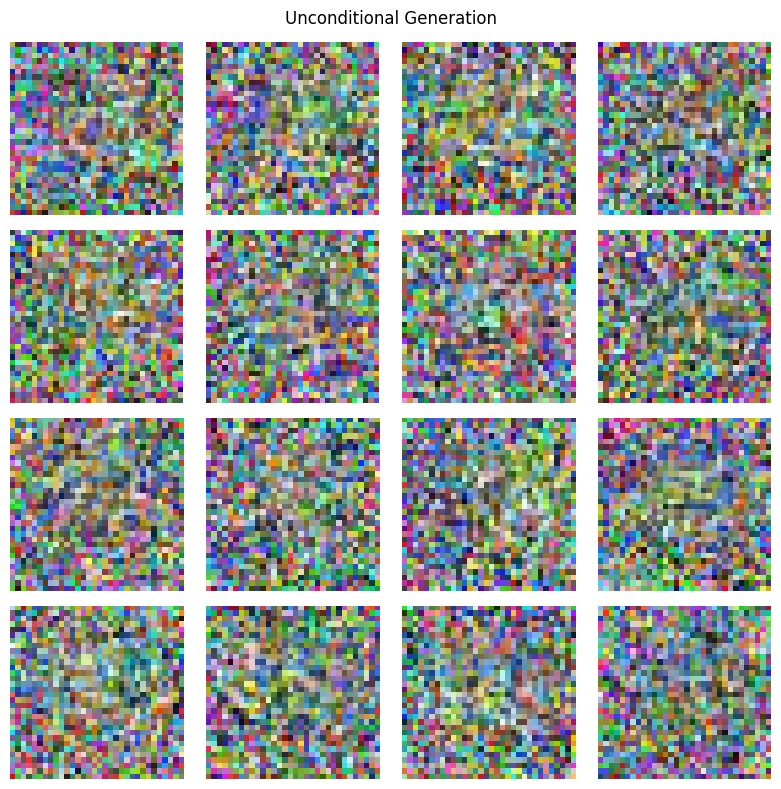

In [27]:
# Unconditional generation - sample from p(x)
print("Generating unconditional samples...")
unconditional_samples = langevin_image_sampling(
    params, 
    n_samples=16, 
    n_steps=100,
    epsilon=0.1,
    noise_scale=0.01,
    init_noise_scale=1.0
)
plot_images(unconditional_samples, title="Unconditional Generation")


Generating conditional samples for each class...


100%|██████████| 100/100 [00:32<00:00,  3.07it/s]


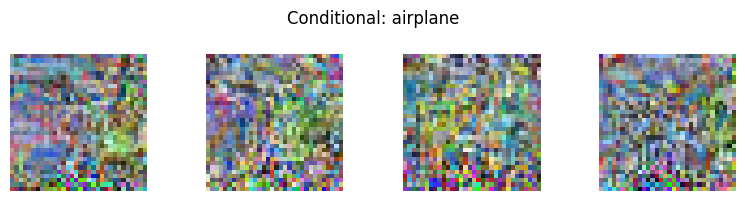

100%|██████████| 100/100 [00:31<00:00,  3.19it/s]


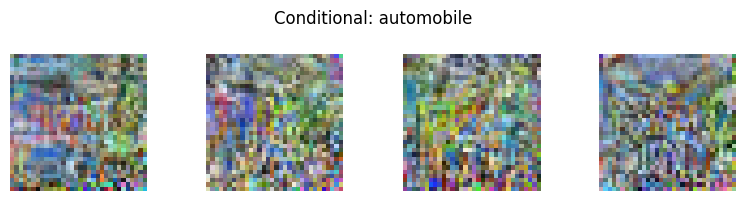

100%|██████████| 100/100 [00:32<00:00,  3.08it/s]


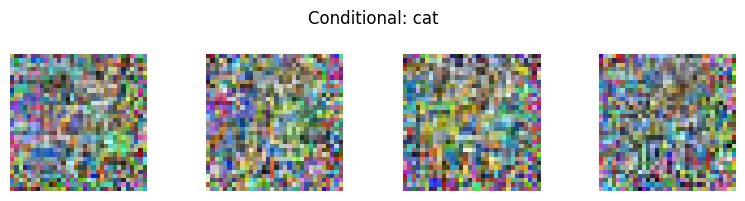

100%|██████████| 100/100 [00:30<00:00,  3.30it/s]


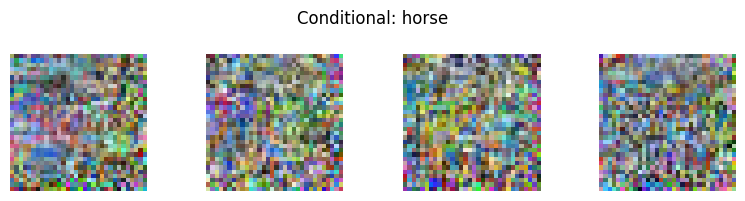

In [28]:
# CIFAR-10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck
cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
                   'dog', 'frog', 'horse', 'ship', 'truck']

print("Generating conditional samples for each class...")
for class_idx in [0, 1, 3, 7]:  # airplane, automobile, cat, horse
    y = onp.array([class_idx] * 4)  # 4 samples per class
    conditional_samples = langevin_image_sampling(
        params, 
        n_samples=4, 
        n_steps=100,
        epsilon=0.1,
        noise_scale=0.01,
        y=y,
        init_noise_scale=1.0
    )
    plot_images(conditional_samples, title=f"Conditional: {cifar10_classes[class_idx]}", nrow=1)


How does the choice of starting points affect the sampling speed?

The choice of starting points significantly affects both the speed and quality of sampling:
- Random noise initialization requires many steps for the Langevin dynamics to find the data manifold
- Starting from slightly perturbed real images speeds up convergence
- The JEM paper uses persistent chains where samples from previous iterations are reused

How well is the density determined for arguments that are not similar to CIFAR-10 images?

The density is poorly calibrated for out-of-distribution inputs:
- Random noise typically has very low log-probability (high energy)
- The gradients in low-density regions may not point towards the data manifold effectively
- This is why sampling can be slow and may require careful hyperparameter tuning

How to implement conditional and unconditional generation?

- Unconditional: Sample from p(x) using logsumexp over class logits. Use get_grads_wrt_input(params, x) without y.
- Conditional: Sample from p(x|y) using the logit for class y. Use get_grads_wrt_input(params, x, y) with labels.
